# Emotions per topic — significance testing

Compares outlet anger scores against the Tagesschau baseline per topic cluster using Mann-Whitney U tests with Benjamini-Hochberg FDR correction.

## 1  Load & merge

Load emotion scores and topic assignments, merge on `row_id`.

In [35]:
import pandas as pd
from pathlib import Path

root = Path.cwd()
if root.name == "04_SentimentAnalysis":
    root = root.parent

df = pd.read_csv(root / "04_SentimentAnalysis/outputs/emotion_fulltext_with_topiclabels.csv")


df = df.rename(columns={"Manual Cluster Label": "topic", "emotion_anger": "anger", "emotion_fear":"fear"})
df["anger"] = pd.to_numeric(df["anger"], errors="coerce")
df["fear"]  = pd.to_numeric(df["fear"], errors="coerce")
df = df.dropna(subset=["anger", "fear", "topic", "source"])


## 2  Pairwise Mann-Whitney U + BH correction

For each *(topic, outlet)* pair with n ≥ 30 on both sides, run a two-sided Mann-Whitney U test and compute rank-biserial effect size r. Apply BH FDR correction across all valid pairs.

In [36]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

REFERENCE   = "Tagesschau"
EFFECT_R_MIN = 0.10   # minimum |r| required to report a significant marker
ALT_OUTLETS = [o for o in df["source"].unique() if o != REFERENCE]
MIN_N       = 20

records  = []
excluded = []

for topic in df["topic"].unique():
    df_t    = df[df["topic"] == topic]
    ts_vals = df_t.loc[df_t["source"] == REFERENCE, "anger"].values

    for outlet in ALT_OUTLETS:
        alt_vals = df_t.loc[df_t["source"] == outlet, "anger"].values

        if len(alt_vals) < MIN_N or len(ts_vals) < MIN_N:
            excluded.append({"topic": topic, "outlet": outlet,
                             "n_outlet": len(alt_vals), "n_tagesschau": len(ts_vals),
                             "reason": f"n < {MIN_N}"})
            continue

        U, p_raw = mannwhitneyu(alt_vals, ts_vals, alternative="two-sided")
        n1, n2   = len(alt_vals), len(ts_vals)
        r        = (2 * U) / (n1 * n2) - 1   # positive = alt outlet angrier than Tagesschau

        records.append({
            "topic":                topic,
            "outlet":               outlet,
            "n_outlet":             n1,
            "n_tagesschau":         n2,
            "mean_anger_outlet":    float(np.mean(alt_vals)),
            "mean_anger_tagesschau": float(np.mean(ts_vals)),
            "U_statistic":          U,
            "p_raw":                p_raw,
            "effect_size_r":        r,
        })

results = pd.DataFrame(records)

reject, p_adj, _, _ = multipletests(results["p_raw"].values, alpha=0.05, method="fdr_bh")
results["p_adjusted"]  = p_adj
results["significant"] = reject & (results["effect_size_r"].abs() >= EFFECT_R_MIN)

# Masked p-value: cells that don't meet the effect size floor are treated as non-significant
results["p_adj_masked"] = results["p_adjusted"].where(
    results["effect_size_r"].abs() >= EFFECT_R_MIN, other=1.0
)

results = results.sort_values("p_adjusted").reset_index(drop=True)
results


,topic,outlet,n_outlet,n_tagesschau,mean_anger_outlet,mean_anger_tagesschau,U_statistic,p_raw,effect_size_r,p_adjusted,significant,p_adj_masked
0,Social Policy & Welfare,Tichys_Einblick,260,471,0.869515,0.659799,104809.0,3.112432e-57,0.711726,2.863438e-55,True,2.863438e-55
1,German Party Politics,Tichys_Einblick,436,388,0.864916,0.676051,138326.0,6.006017e-56,0.635368,2.762768e-54,True,2.762768e-54
2,German Economy & Industry,Tichys_Einblick,222,597,0.841044,0.657513,108932.0,1.270280e-45,0.643835,3.895526e-44,True,3.895526e-44
3,"Energy, Climate & Environment",Tichys_Einblick,162,461,0.848386,0.675471,62324.0,7.902185e-37,0.669050,1.817503e-35,True,1.817503e-35
4,Miscellaneous,Tichys_Einblick,212,612,0.782626,0.577318,102207.0,7.410364e-36,0.575518,1.363507e-34,True,1.363507e-34
...,...,...,...,...,...,...,...,...,...,...,...,...
87,US & Transatlantic Politics,Antispiegel,52,655,0.737026,0.733886,17746.0,6.137467e-01,0.042043,6.416443e-01,False,1.000000e+00
88,Russia (-Ukraine) Diplomacy & Sanctions,RT_de,1089,400,0.612221,0.612843,220570.0,7.064873e-01,0.012718,7.303014e-01,False,1.000000e+00
89,Russia (-Ukraine) Diplomacy & Sanctions,Nius,66,400,0.602571,0.612843,13464.0,7.948926e-01,0.020000,8.125569e-01,False,1.000000e+00
90,Russia-Ukraine War,Nius,30,299,0.685481,0.682301,4549.0,8.982653e-01,0.014270,9.081363e-01,False,1.000000e+00


## 3  Effect-size heatmap (anger)

Rank-biserial effect size *r* per topic × alternative outlet, relative to the Tagesschau baseline. Diverging scale centered at 0: red = outlet expresses **more anger** than Tagesschau, blue = **less**. Cells with n < 30 (on either side) or |*r*| below the practical threshold are greyed out; `*`/`**`/`***` mark BH-significant pairs.

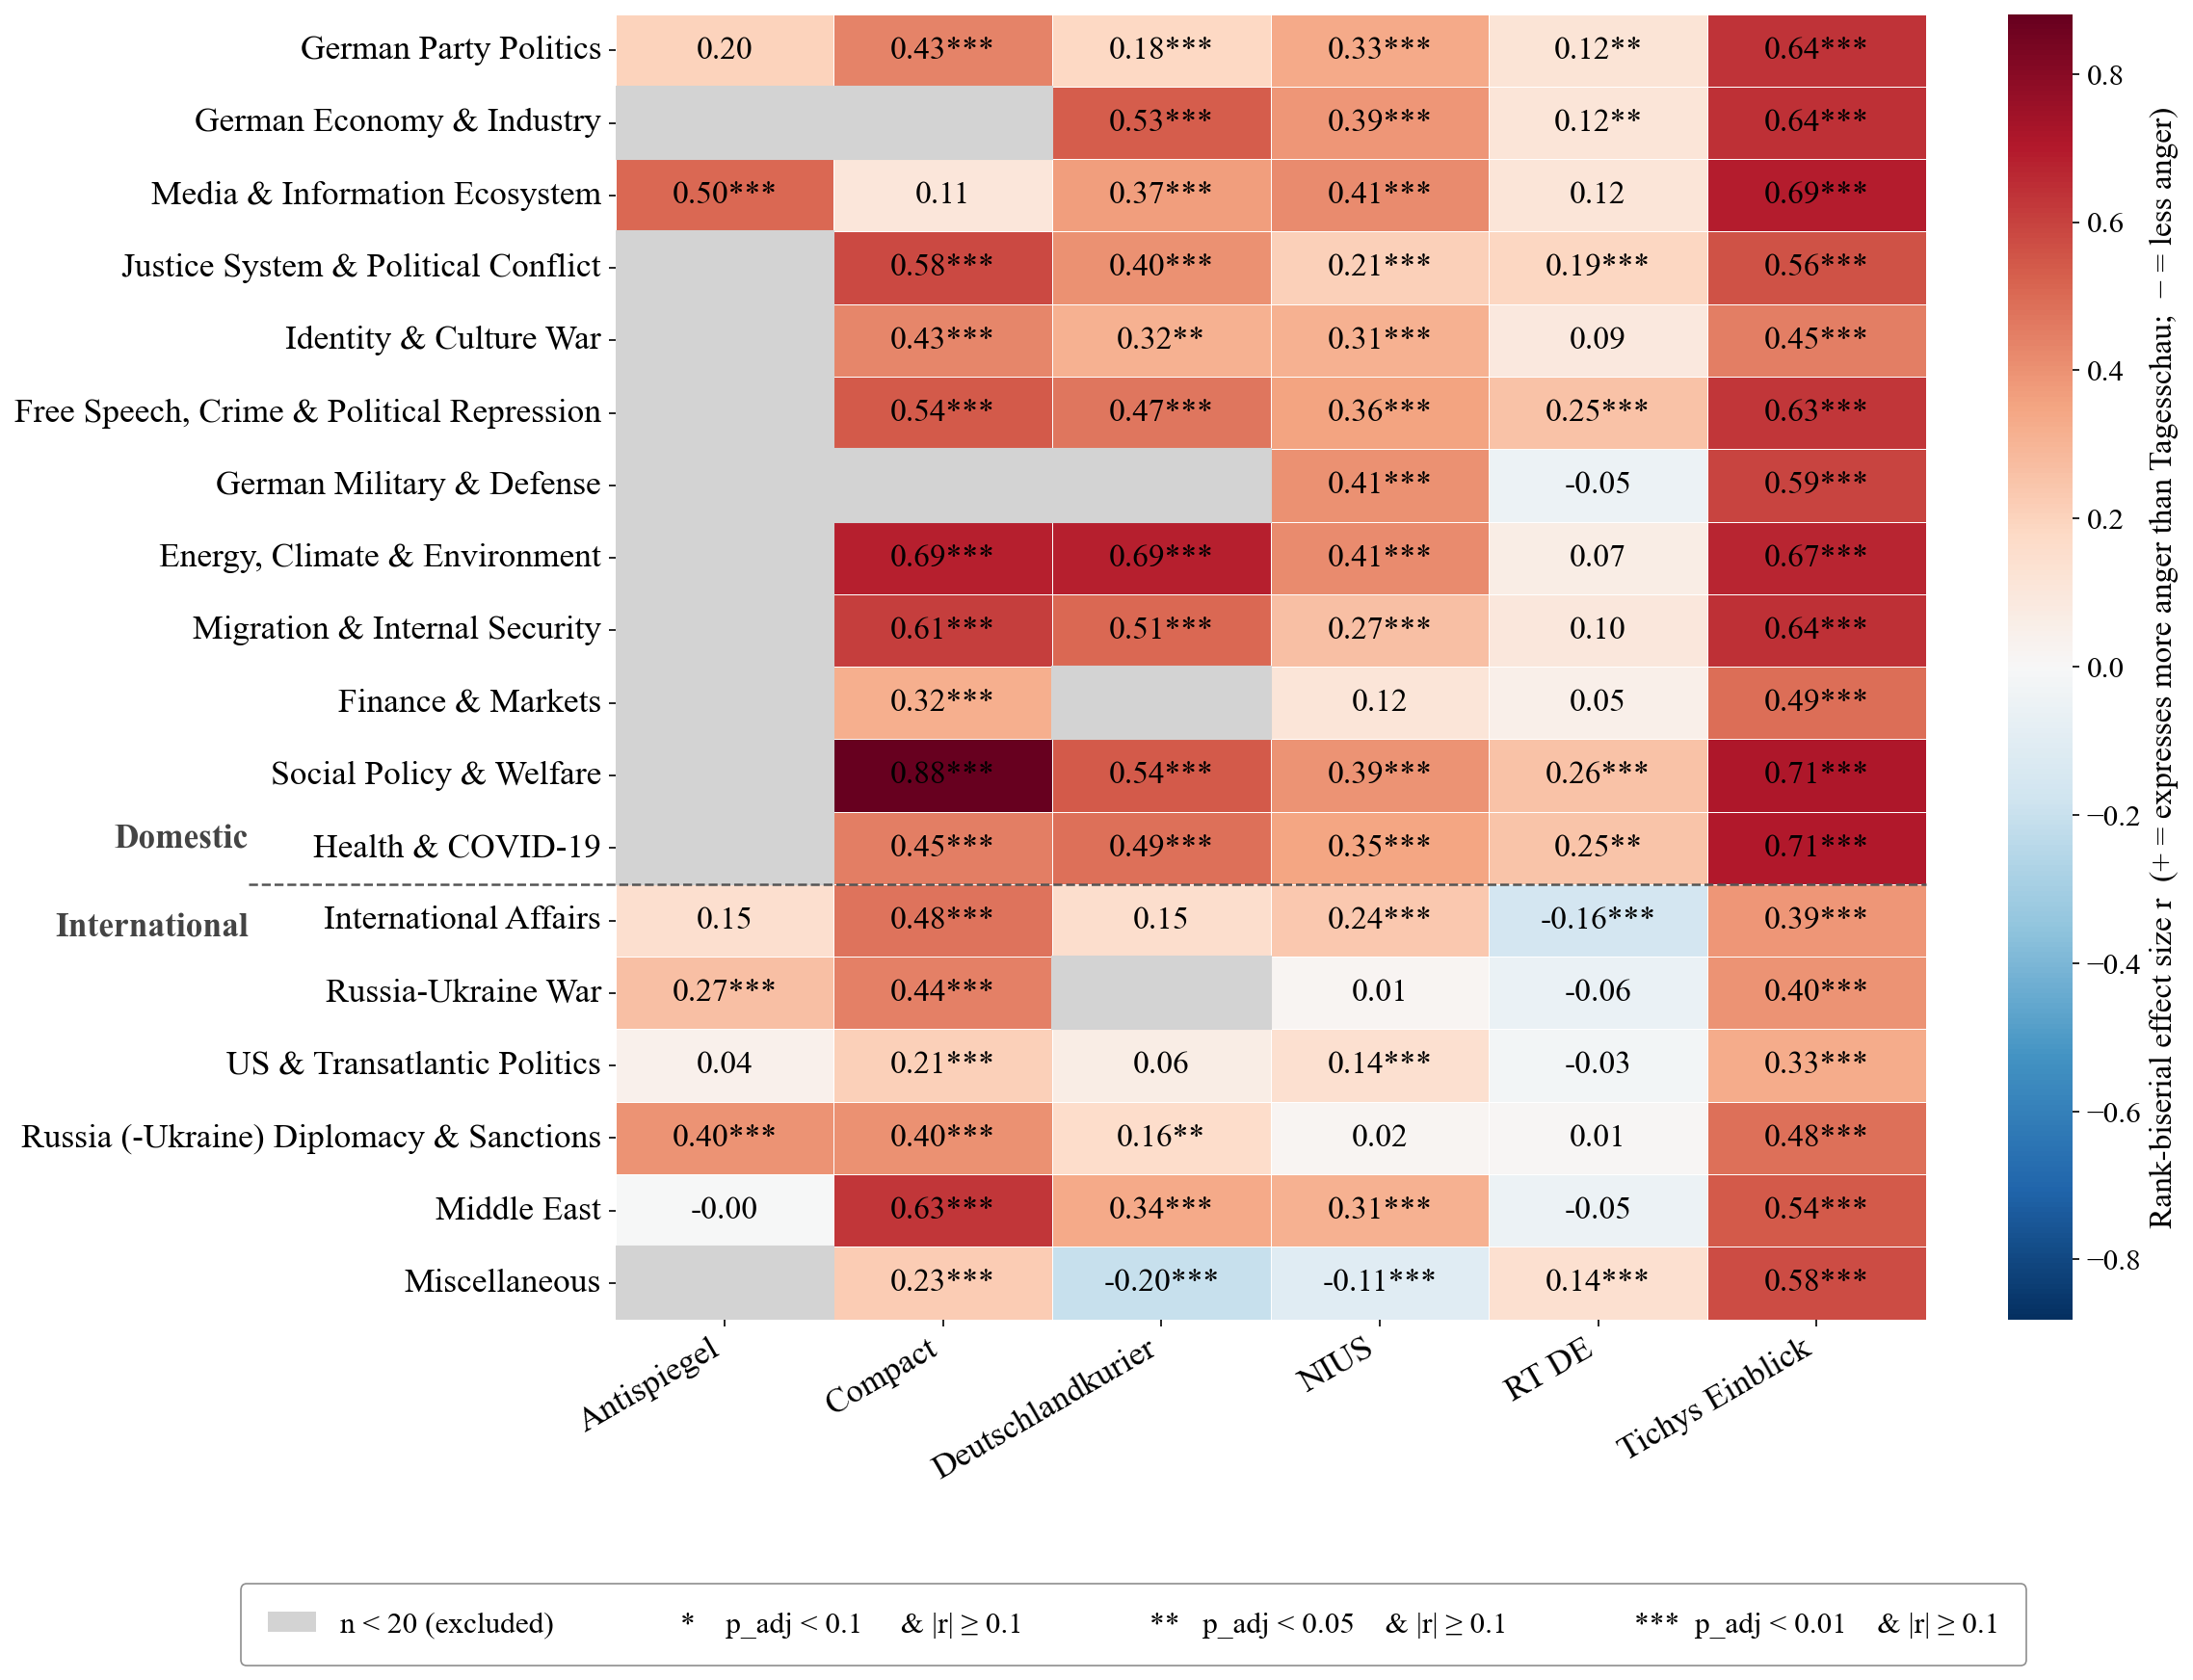

In [37]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

mpl.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "Times New Roman",
    "font.size":         17,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "axes.titlesize":    18,
    "axes.titleweight":  "bold",
    "axes.labelsize":    18,
    "xtick.labelsize":   17,
    "ytick.labelsize":   17,
    "legend.fontsize":   16,
    "legend.frameon":    True,
    "savefig.bbox":      "tight",
    "savefig.dpi":       300,
})

TNR_FONT = {"family": "Times New Roman", "size": 14}

OUTLET_DISPLAY = {
    "Nius":            "NIUS",
    "Tichys_Einblick": "Tichys Einblick",
    "RT_de":           "RT DE",
}

ANGER_COL = "anger"

def _sig_marker(p_adj):
    if p_adj < 0.01: return "***"
    if p_adj < 0.05: return "**"
    if p_adj < 0.1:  return "*"
    return ""

# ── Sort topics: Domestic → International → Other ────────────────────────────
_DOMESTIC = {
    "Social Policy & Welfare", "Health & COVID-19", "Energy, Climate & Environment",
    "German Economy & Industry", "Migration & Internal Security", "German Party Politics",
    "Free Speech, Crime & Political Repression", "Media & Information Ecosystem",
    "Justice System & Political Conflict", "Identity & Culture War",
    "Finance & Markets", "German Military & Defense", "Green Politics & Woke Culture",
}
_INTERNATIONAL = {
    "Middle East", "Russia (-Ukraine) Diplomacy & Sanctions",
    "US & Transatlantic Politics", "Russia-Ukraine War", "International Affairs",
}
def _geo_rank(t):
    if t in _DOMESTIC:      return 0
    if t in _INTERNATIONAL: return 1
    return 2

topics = sorted(df["topic"].dropna().unique(), key=_geo_rank)

def _add_geo_brackets(ax, topics_ordered):
    """Draw a horizontal separator line between the last Domestic and first International row."""
    last_dom = None
    first_intl = None
    for i, t in enumerate(topics_ordered):
        if t in _DOMESTIC:
            last_dom = i
        elif t in _INTERNATIONAL and first_intl is None:
            first_intl = i
    if last_dom is None or first_intl is None:
        return
    sep_y = first_intl   # exact boundary between last domestic and first international row
    label_x = -0.28      # x-position (axis coords) of the geo labels — close to topic labels
    ax.plot([label_x, 1.0], [sep_y, sep_y], color="#555555", linewidth=1.2,
            linestyle="--", zorder=4, transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(label_x, sep_y - 0.4, "Domestic",
            ha="right", va="bottom", fontsize=17, color="#444444", fontweight="bold",
            fontfamily="Times New Roman",
            transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(label_x, sep_y + 0.4, "International",
            ha="right", va="top", fontsize=17, color="#444444", fontweight="bold",
            fontfamily="Times New Roman",
            transform=ax.get_yaxis_transform(), clip_on=False)

# ── Build pivots ──────────────────────────────────────────────────────────────
all_outlets = sorted(df["source"].unique())

sig_lookup = (
    results
    .set_index(["topic", "outlet"])["p_adj_masked"]
    .to_dict()
)

legend_patches = [
    mpatches.Patch(facecolor="lightgrey", label=f"n < {MIN_N} (excluded)"),
    plt.Line2D([0], [0], color="none", label=f"*    p_adj < 0.1     & |r| \u2265 {EFFECT_R_MIN}"),
    plt.Line2D([0], [0], color="none", label=f"**   p_adj < 0.05    & |r| \u2265 {EFFECT_R_MIN}"),
    plt.Line2D([0], [0], color="none", label=f"***  p_adj < 0.01    & |r| \u2265 {EFFECT_R_MIN}"),
]

def _style_heatmap(ax, cbar_label):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.set_xticklabels(
        [OUTLET_DISPLAY.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()]
    )
    for tick in ax.get_xticklabels():
        tick.set_fontsize(17)
        tick.set_fontfamily("Times New Roman")
        tick.set_ha("right")
    for tick in ax.get_yticklabels():
        tick.set_fontsize(17)
        tick.set_fontfamily("Times New Roman")
    cbar = ax.collections[0].colorbar
    if cbar is not None:
        cbar.set_label(cbar_label, fontsize=16, fontfamily="Times New Roman")
        for t in cbar.ax.get_yticklabels():
            t.set_fontfamily("Times New Roman")
            t.set_fontsize(15)

def _add_legend(fig, handles):
    leg = fig.legend(
        handles=handles, loc="upper center",
        bbox_to_anchor=(0.5, -0.02), ncol=4,
        frameon=True, fancybox=True, framealpha=0.95,
        edgecolor="#888888", borderpad=0.9, handlelength=1.6,
        columnspacing=1.8, prop={"family": "Times New Roman", "size": 15},
    )
    leg.get_frame().set_linewidth(0.8)

# ── Effect size r: anger (outlet vs. Tagesschau) ──────────────────────────────
r_pivot  = results.set_index(["topic", "outlet"])["effect_size_r"].unstack("outlet")
r_pivot  = r_pivot.reindex(index=[t for t in topics if t in r_pivot.index])
r_topics = r_pivot.index.tolist()
r_outlets= r_pivot.columns.tolist()

grey_r = pd.DataFrame(False, index=r_topics, columns=r_outlets)
for rec in excluded:
    t, o = rec["topic"], rec["outlet"]
    if t in grey_r.index and o in grey_r.columns:
        grey_r.at[t, o] = True

r_spread = max(float(np.nanmax(np.abs(r_pivot.to_numpy(dtype=float)))), 1e-6)

CBAR_LABEL_ANGER = (
    "Rank-biserial effect size r  "
    "(+ = expresses more anger than Tagesschau;  − = less anger)"
)

fig2, ax2 = plt.subplots(figsize=(max(16, 1.6 * len(r_outlets)),
                                  max(9,  0.6 * len(r_topics))))

sns.heatmap(r_pivot, ax=ax2, annot=False,
            cmap="RdBu_r", center=0, vmin=-r_spread, vmax=r_spread,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": CBAR_LABEL_ANGER})

for ri, topic in enumerate(r_topics):
    for ci, outlet in enumerate(r_outlets):
        val    = r_pivot.at[topic, outlet] if topic in r_pivot.index else float("nan")
        marker = _sig_marker(sig_lookup.get((topic, outlet), 1.0))
        grey   = grey_r.at[topic, outlet] if topic in grey_r.index else True
        if grey:
            ax2.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            if not np.isnan(val):
                ax2.text(ci+0.5, ri+0.5, f"{val:.2f}", ha="center", va="center",
                         fontsize=16, color="grey", zorder=3,
                         fontfamily="Times New Roman")
        else:
            ax2.text(ci+0.5, ri+0.5, f"{val:.2f}{marker}" if not np.isnan(val) else "",
                     ha="center", va="center", fontsize=16, color="black", zorder=3,
                     fontfamily="Times New Roman")

_style_heatmap(ax2, CBAR_LABEL_ANGER)
_add_geo_brackets(ax2, r_topics)
_add_legend(fig2, legend_patches)
plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()


## 3a  Topic-level effect-size heatmap (anger) — ordered by cluster

Same MWU + BH significance test as above, but at the granular `Manual Topic Label` level. Topics are stacked into one long heatmap, ordered by cluster geo group (Domestic → International → Other) and then by cluster name. Horizontal separators mark cluster boundaries; cluster band labels run along the left.

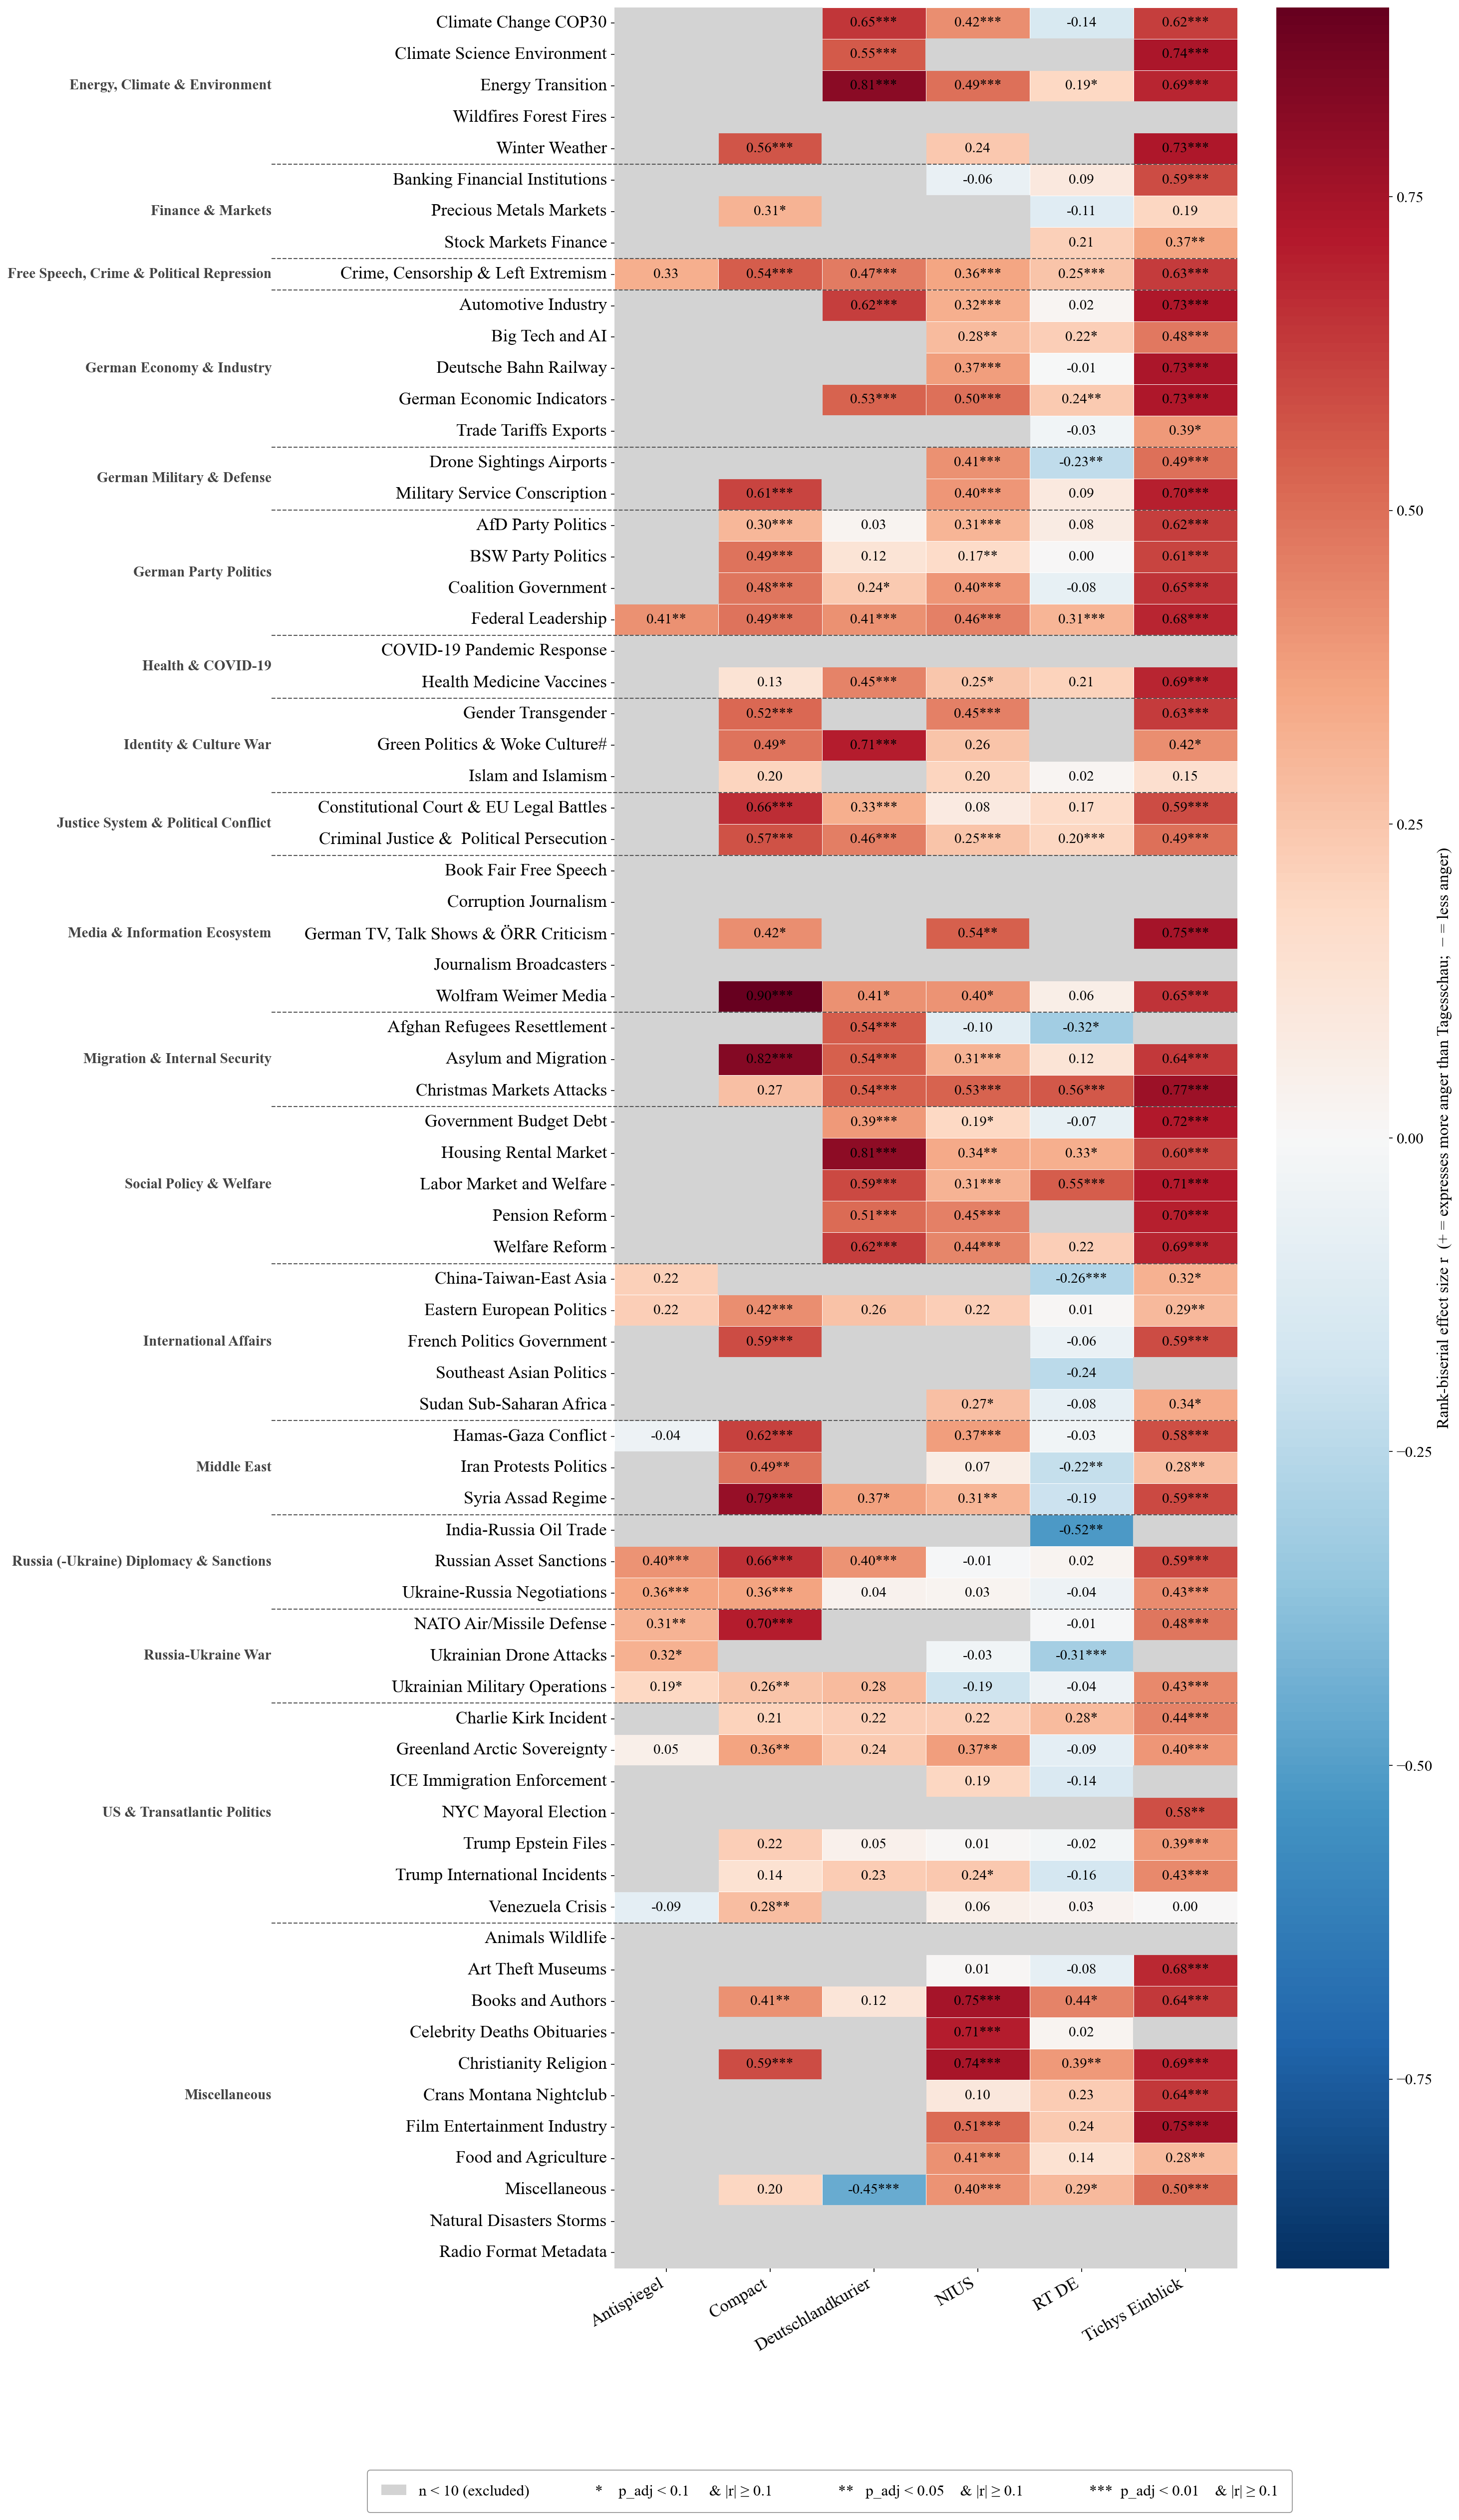

In [38]:
# ── Topic-level (Manual Topic Label) effect-size heatmap, ordered by cluster ─
# Uses `df` from the load cell at the top — note that there `Manual Cluster Label`
# is renamed to `topic`, and `Manual Topic Label` (granular topic) is preserved.

MIN_N_TOPIC = 10  # lower threshold than cluster-level; topics have smaller per-outlet n


def _topic_level_heatmap(emo_col, cbar_label, fig_id):
    df_t = df.dropna(subset=["Manual Topic Label"])
    alt_outlets = sorted(o for o in df_t["source"].unique() if o != REFERENCE)

    records, excluded = [], []
    for topic in df_t["Manual Topic Label"].unique():
        sub     = df_t[df_t["Manual Topic Label"] == topic]
        cluster = sub["topic"].iloc[0]
        ts_vals = sub.loc[sub["source"] == REFERENCE, emo_col].values

        for outlet in alt_outlets:
            alt_vals = sub.loc[sub["source"] == outlet, emo_col].values
            if len(alt_vals) < MIN_N_TOPIC or len(ts_vals) < MIN_N_TOPIC:
                excluded.append((topic, outlet))
                continue
            U, p_raw = mannwhitneyu(alt_vals, ts_vals, alternative="two-sided")
            n1, n2   = len(alt_vals), len(ts_vals)
            r        = (2 * U) / (n1 * n2) - 1
            records.append({"topic": topic, "outlet": outlet, "cluster": cluster,
                            "p_raw": p_raw, "effect_size_r": r})

    res = pd.DataFrame(records)
    _, p_adj, _, _ = multipletests(res["p_raw"].values, alpha=0.05, method="fdr_bh")
    res["p_adj_masked"] = pd.Series(p_adj).where(
        res["effect_size_r"].abs() >= EFFECT_R_MIN, other=1.0
    )

    # Order topics: Domestic → International → Other; then cluster; then topic name
    def _geo_rank(c):
        return 0 if c in _DOMESTIC else 1 if c in _INTERNATIONAL else 2

    tc = (df_t[["Manual Topic Label", "topic"]]
          .drop_duplicates()
          .rename(columns={"Manual Topic Label": "t", "topic": "cluster"}))
    tc["g"] = tc["cluster"].map(_geo_rank)
    tc = tc.sort_values(["g", "cluster", "t"]).reset_index(drop=True)
    topics_ordered   = tc["t"].tolist()
    topic_to_cluster = dict(zip(tc["t"], tc["cluster"]))

    r_pivot   = (res.set_index(["topic", "outlet"])["effect_size_r"]
                 .unstack("outlet")
                 .reindex(index=topics_ordered, columns=alt_outlets))
    sig_lkp   = res.set_index(["topic", "outlet"])["p_adj_masked"].to_dict()
    excl_set  = set(excluded)
    r_spread  = max(float(np.nanmax(np.abs(r_pivot.to_numpy(dtype=float)))), 1e-6)

    n_rows, n_cols = r_pivot.shape
    fig, ax = plt.subplots(num=fig_id,
                           figsize=(max(16, 1.6 * n_cols), max(20, 0.45 * n_rows)))
    sns.heatmap(r_pivot, ax=ax, annot=False,
                cmap="RdBu_r", center=0, vmin=-r_spread, vmax=r_spread,
                linewidths=0.4, linecolor="white",
                cbar_kws={"label": cbar_label})

    for ri, topic in enumerate(topics_ordered):
        for ci, outlet in enumerate(r_pivot.columns):
            val    = r_pivot.at[topic, outlet]
            marker = _sig_marker(sig_lkp.get((topic, outlet), 1.0))
            if (topic, outlet) in excl_set or pd.isna(val):
                ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
                if not pd.isna(val):
                    ax.text(ci + 0.5, ri + 0.5, f"{val:.2f}", ha="center", va="center",
                            fontsize=14, color="grey", zorder=3,
                            fontfamily="Times New Roman")
            else:
                ax.text(ci + 0.5, ri + 0.5, f"{val:.2f}{marker}",
                        ha="center", va="center", fontsize=14, color="black", zorder=3,
                        fontfamily="Times New Roman")

    _style_heatmap(ax, cbar_label)
    _add_cluster_brackets(ax, topics_ordered, topic_to_cluster)

    legend = [
        mpatches.Patch(facecolor="lightgrey", label=f"n < {MIN_N_TOPIC} (excluded)"),
        plt.Line2D([0], [0], color="none", label=f"*    p_adj < 0.1     & |r| \u2265 {EFFECT_R_MIN}"),
        plt.Line2D([0], [0], color="none", label=f"**   p_adj < 0.05    & |r| \u2265 {EFFECT_R_MIN}"),
        plt.Line2D([0], [0], color="none", label=f"***  p_adj < 0.01    & |r| \u2265 {EFFECT_R_MIN}"),
    ]
    _add_legend(fig, legend)
    plt.tight_layout()
    plt.subplots_adjust(left=0.32, bottom=0.06)
    plt.show()
    return res


def _add_cluster_brackets(ax, topics_ordered, topic_to_cluster, label_x=-0.55):
    starts, ends = {}, {}
    for i, t in enumerate(topics_ordered):
        c = topic_to_cluster[t]
        starts.setdefault(c, i)
        ends[c] = i
    for cluster, start in starts.items():
        mid = (start + ends[cluster] + 1) / 2
        if start > 0:
            ax.plot([label_x, 1.0], [start, start], color="#555555", linewidth=1.0,
                    linestyle="--", zorder=4,
                    transform=ax.get_yaxis_transform(), clip_on=False)
        ax.text(label_x, mid, cluster, ha="right", va="center",
                fontsize=14, color="#444444", fontweight="bold",
                fontfamily="Times New Roman",
                transform=ax.get_yaxis_transform(), clip_on=False)


results_topic_anger = _topic_level_heatmap("anger", CBAR_LABEL_ANGER, fig_id="topic_anger")

## 5  Fear — Pairwise Mann-Whitney U + BH correction

For each *(topic, outlet)* pair with n ≥ 30 on both sides, run a two-sided Mann-Whitney U test comparing **fear** scores against Tagesschau, then apply Benjamini-Hochberg FDR correction.

In [39]:
records_fear  = []
excluded_fear = []

for topic in df["topic"].unique():
    df_t    = df[df["topic"] == topic]
    ts_vals = df_t.loc[df_t["source"] == REFERENCE, "fear"].values

    for outlet in ALT_OUTLETS:
        alt_vals = df_t.loc[df_t["source"] == outlet, "fear"].values

        if len(alt_vals) < MIN_N or len(ts_vals) < MIN_N:
            excluded_fear.append({"topic": topic, "outlet": outlet,
                                  "n_outlet": len(alt_vals), "n_tagesschau": len(ts_vals),
                                  "reason": f"n < {MIN_N}"})
            continue

        U, p_raw = mannwhitneyu(alt_vals, ts_vals, alternative="two-sided")
        n1, n2   = len(alt_vals), len(ts_vals)
        r        = (2 * U) / (n1 * n2) - 1   # positive = alt outlet angrier than Tagesschau

        records_fear.append({
            "topic":               topic,
            "outlet":              outlet,
            "n_outlet":            n1,
            "n_tagesschau":        n2,
            "mean_fear_outlet":    float(np.mean(alt_vals)),
            "mean_fear_tagesschau": float(np.mean(ts_vals)),
            "U_statistic":         U,
            "p_raw":               p_raw,
            "effect_size_r":       r,
        })

results_fear = pd.DataFrame(records_fear)

reject_f, p_adj_f, _, _ = multipletests(results_fear["p_raw"].values, alpha=0.05, method="fdr_bh")
results_fear["p_adjusted"]  = p_adj_f
results_fear["significant"] = reject_f & (results_fear["effect_size_r"].abs() >= EFFECT_R_MIN)

# Masked p-value: cells that don't meet the effect size floor are treated as non-significant
results_fear["p_adj_masked"] = results_fear["p_adjusted"].where(
    results_fear["effect_size_r"].abs() >= EFFECT_R_MIN, other=1.0
)

results_fear = results_fear.sort_values("p_adjusted").reset_index(drop=True)
results_fear


,topic,outlet,n_outlet,n_tagesschau,mean_fear_outlet,mean_fear_tagesschau,U_statistic,p_raw,effect_size_r,p_adjusted,significant,p_adj_masked
0,German Party Politics,Compact,264,388,0.284657,0.163659,72631.0,1.186331e-19,0.418131,5.664704e-18,True,5.664704e-18
1,Miscellaneous,Nius,449,612,0.180464,0.269513,92684.0,1.231457e-19,-0.325415,5.664704e-18,True,5.664704e-18
2,German Economy & Industry,Nius,207,597,0.353806,0.206775,86924.0,2.561382e-18,0.406776,7.854905e-17,True,7.854905e-17
3,Social Policy & Welfare,Tichys_Einblick,260,471,0.250081,0.167806,83873.0,1.186818e-16,0.369802,2.729682e-15,True,2.729682e-15
4,German Party Politics,Tichys_Einblick,436,388,0.220276,0.163659,111784.0,1.515950e-15,0.321574,2.324457e-14,True,2.324457e-14
...,...,...,...,...,...,...,...,...,...,...,...,...
87,Russia (-Ukraine) Diplomacy & Sanctions,Deutschlandkurier,104,400,0.179714,0.170062,20709.5,9.457692e-01,-0.004351,9.561623e-01,False,1.000000e+00
88,Russia-Ukraine War,Compact,74,299,0.334892,0.321856,11000.0,9.400052e-01,-0.005695,9.561623e-01,False,1.000000e+00
89,Identity & Culture War,Nius,159,42,0.270089,0.263472,3310.0,9.322586e-01,-0.008685,9.561623e-01,False,1.000000e+00
90,Health & COVID-19,RT_de,38,190,0.247552,0.239862,3644.0,9.280882e-01,0.009418,9.561623e-01,False,1.000000e+00


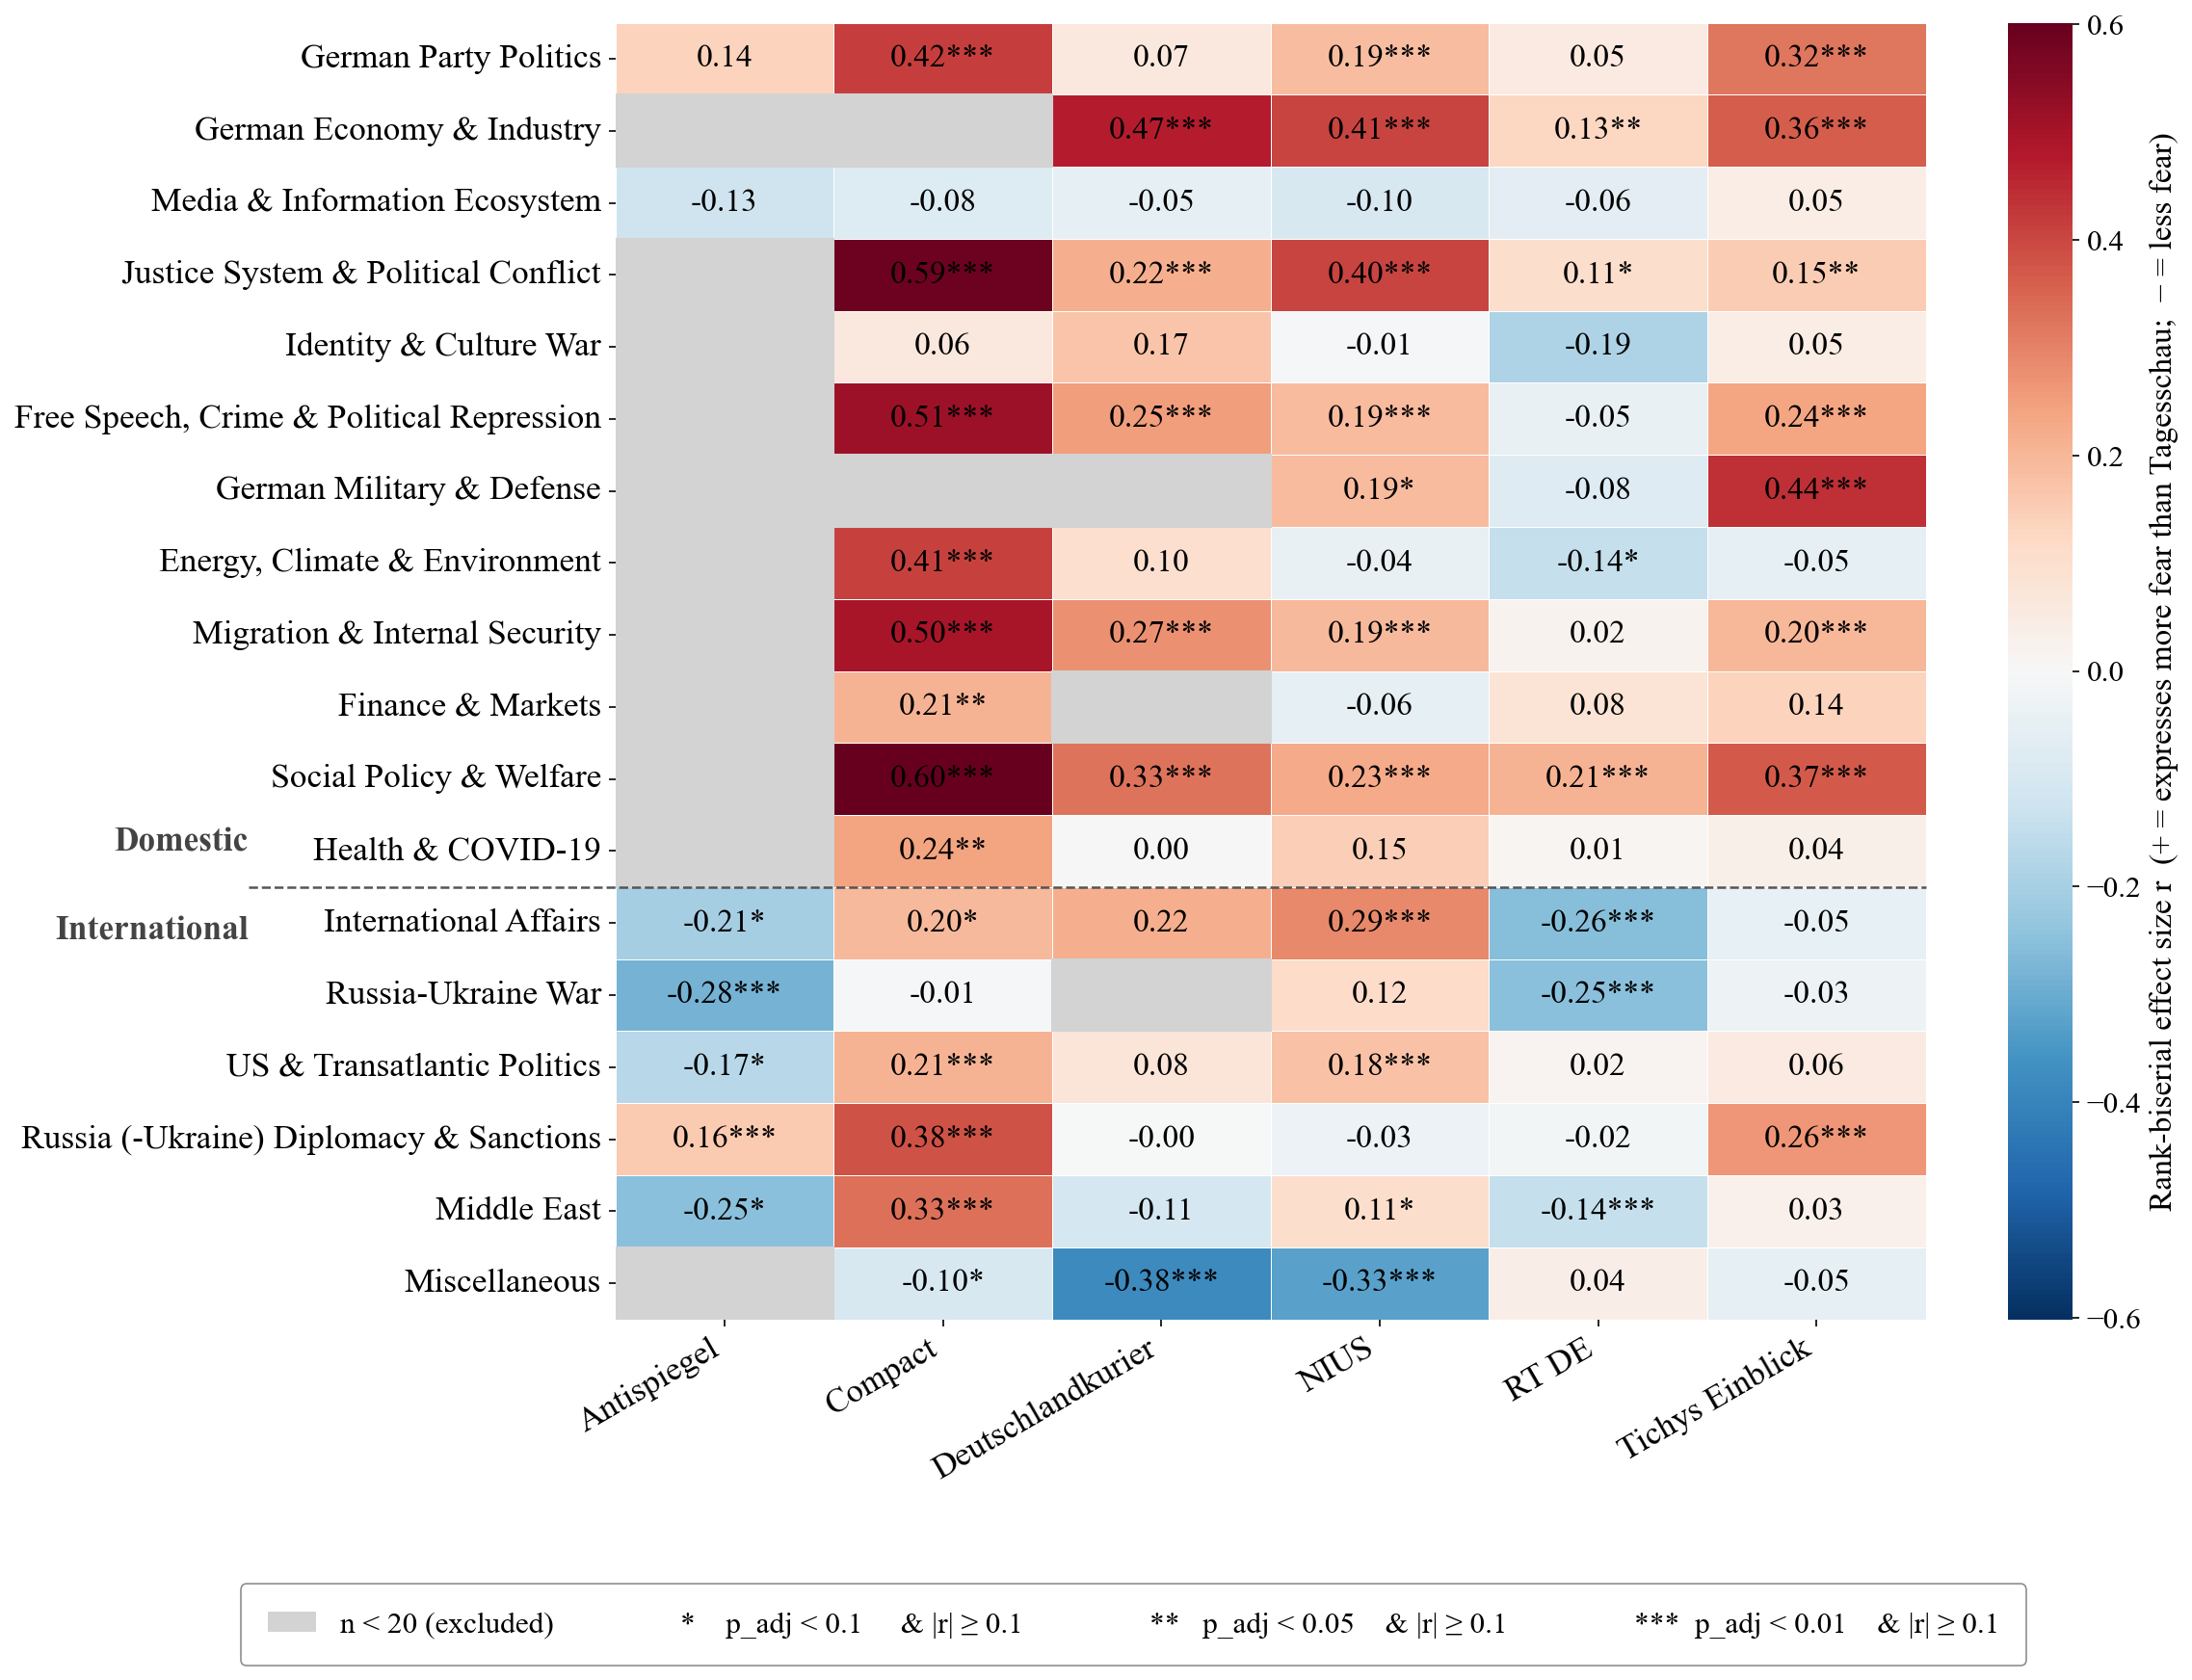

In [40]:
# topics already geo-sorted from anger cell above

FEAR_COL = "fear"

sig_lookup_f = (
    results_fear
    .set_index(["topic", "outlet"])["p_adj_masked"]
    .to_dict()
)

# ── Effect size r: fear (outlet vs. Tagesschau) ───────────────────────────────
r_pivot_f   = results_fear.set_index(["topic", "outlet"])["effect_size_r"].unstack("outlet")
r_pivot_f   = r_pivot_f.reindex(index=[t for t in topics if t in r_pivot_f.index])
r_topics_f  = r_pivot_f.index.tolist()
r_outlets_f = r_pivot_f.columns.tolist()

grey_r_f = pd.DataFrame(False, index=r_topics_f, columns=r_outlets_f)
for rec in excluded_fear:
    t, o = rec["topic"], rec["outlet"]
    if t in grey_r_f.index and o in grey_r_f.columns:
        grey_r_f.at[t, o] = True

r_spread_f = max(float(np.nanmax(np.abs(r_pivot_f.to_numpy(dtype=float)))), 1e-6)

CBAR_LABEL_FEAR = (
    "Rank-biserial effect size r  "
    "(+ = expresses more fear than Tagesschau;  − = less fear)"
)

fig2, ax2 = plt.subplots(figsize=(max(16, 1.6 * len(r_outlets_f)),
                                  max(9,  0.6 * len(r_topics_f))))

sns.heatmap(r_pivot_f, ax=ax2, annot=False,
            cmap="RdBu_r", center=0, vmin=-r_spread_f, vmax=r_spread_f,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": CBAR_LABEL_FEAR})

for ri, topic in enumerate(r_topics_f):
    for ci, outlet in enumerate(r_outlets_f):
        val    = r_pivot_f.at[topic, outlet] if topic in r_pivot_f.index else float("nan")
        marker = _sig_marker(sig_lookup_f.get((topic, outlet), 1.0))
        grey   = grey_r_f.at[topic, outlet] if topic in grey_r_f.index else True
        if grey:
            ax2.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            if not np.isnan(val):
                ax2.text(ci+0.5, ri+0.5, f"{val:.2f}", ha="center", va="center",
                         fontsize=16, color="grey", zorder=3,
                         fontfamily="Times New Roman")
        else:
            ax2.text(ci+0.5, ri+0.5, f"{val:.2f}{marker}" if not np.isnan(val) else "",
                     ha="center", va="center", fontsize=16, color="black", zorder=3,
                     fontfamily="Times New Roman")

_style_heatmap(ax2, CBAR_LABEL_FEAR)
_add_geo_brackets(ax2, r_topics_f)
_add_legend(fig2, legend_patches)
plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()


## 6a  Topic-level effect-size heatmap (fear) — ordered by cluster

Same MWU + BH significance test as the cluster-level fear heatmap, but at the granular `Manual Topic Label` level. Topics are stacked into one long heatmap, ordered by cluster geo group (Domestic → International → Other) and then by cluster name. Horizontal separators mark cluster boundaries; cluster band labels run along the left.

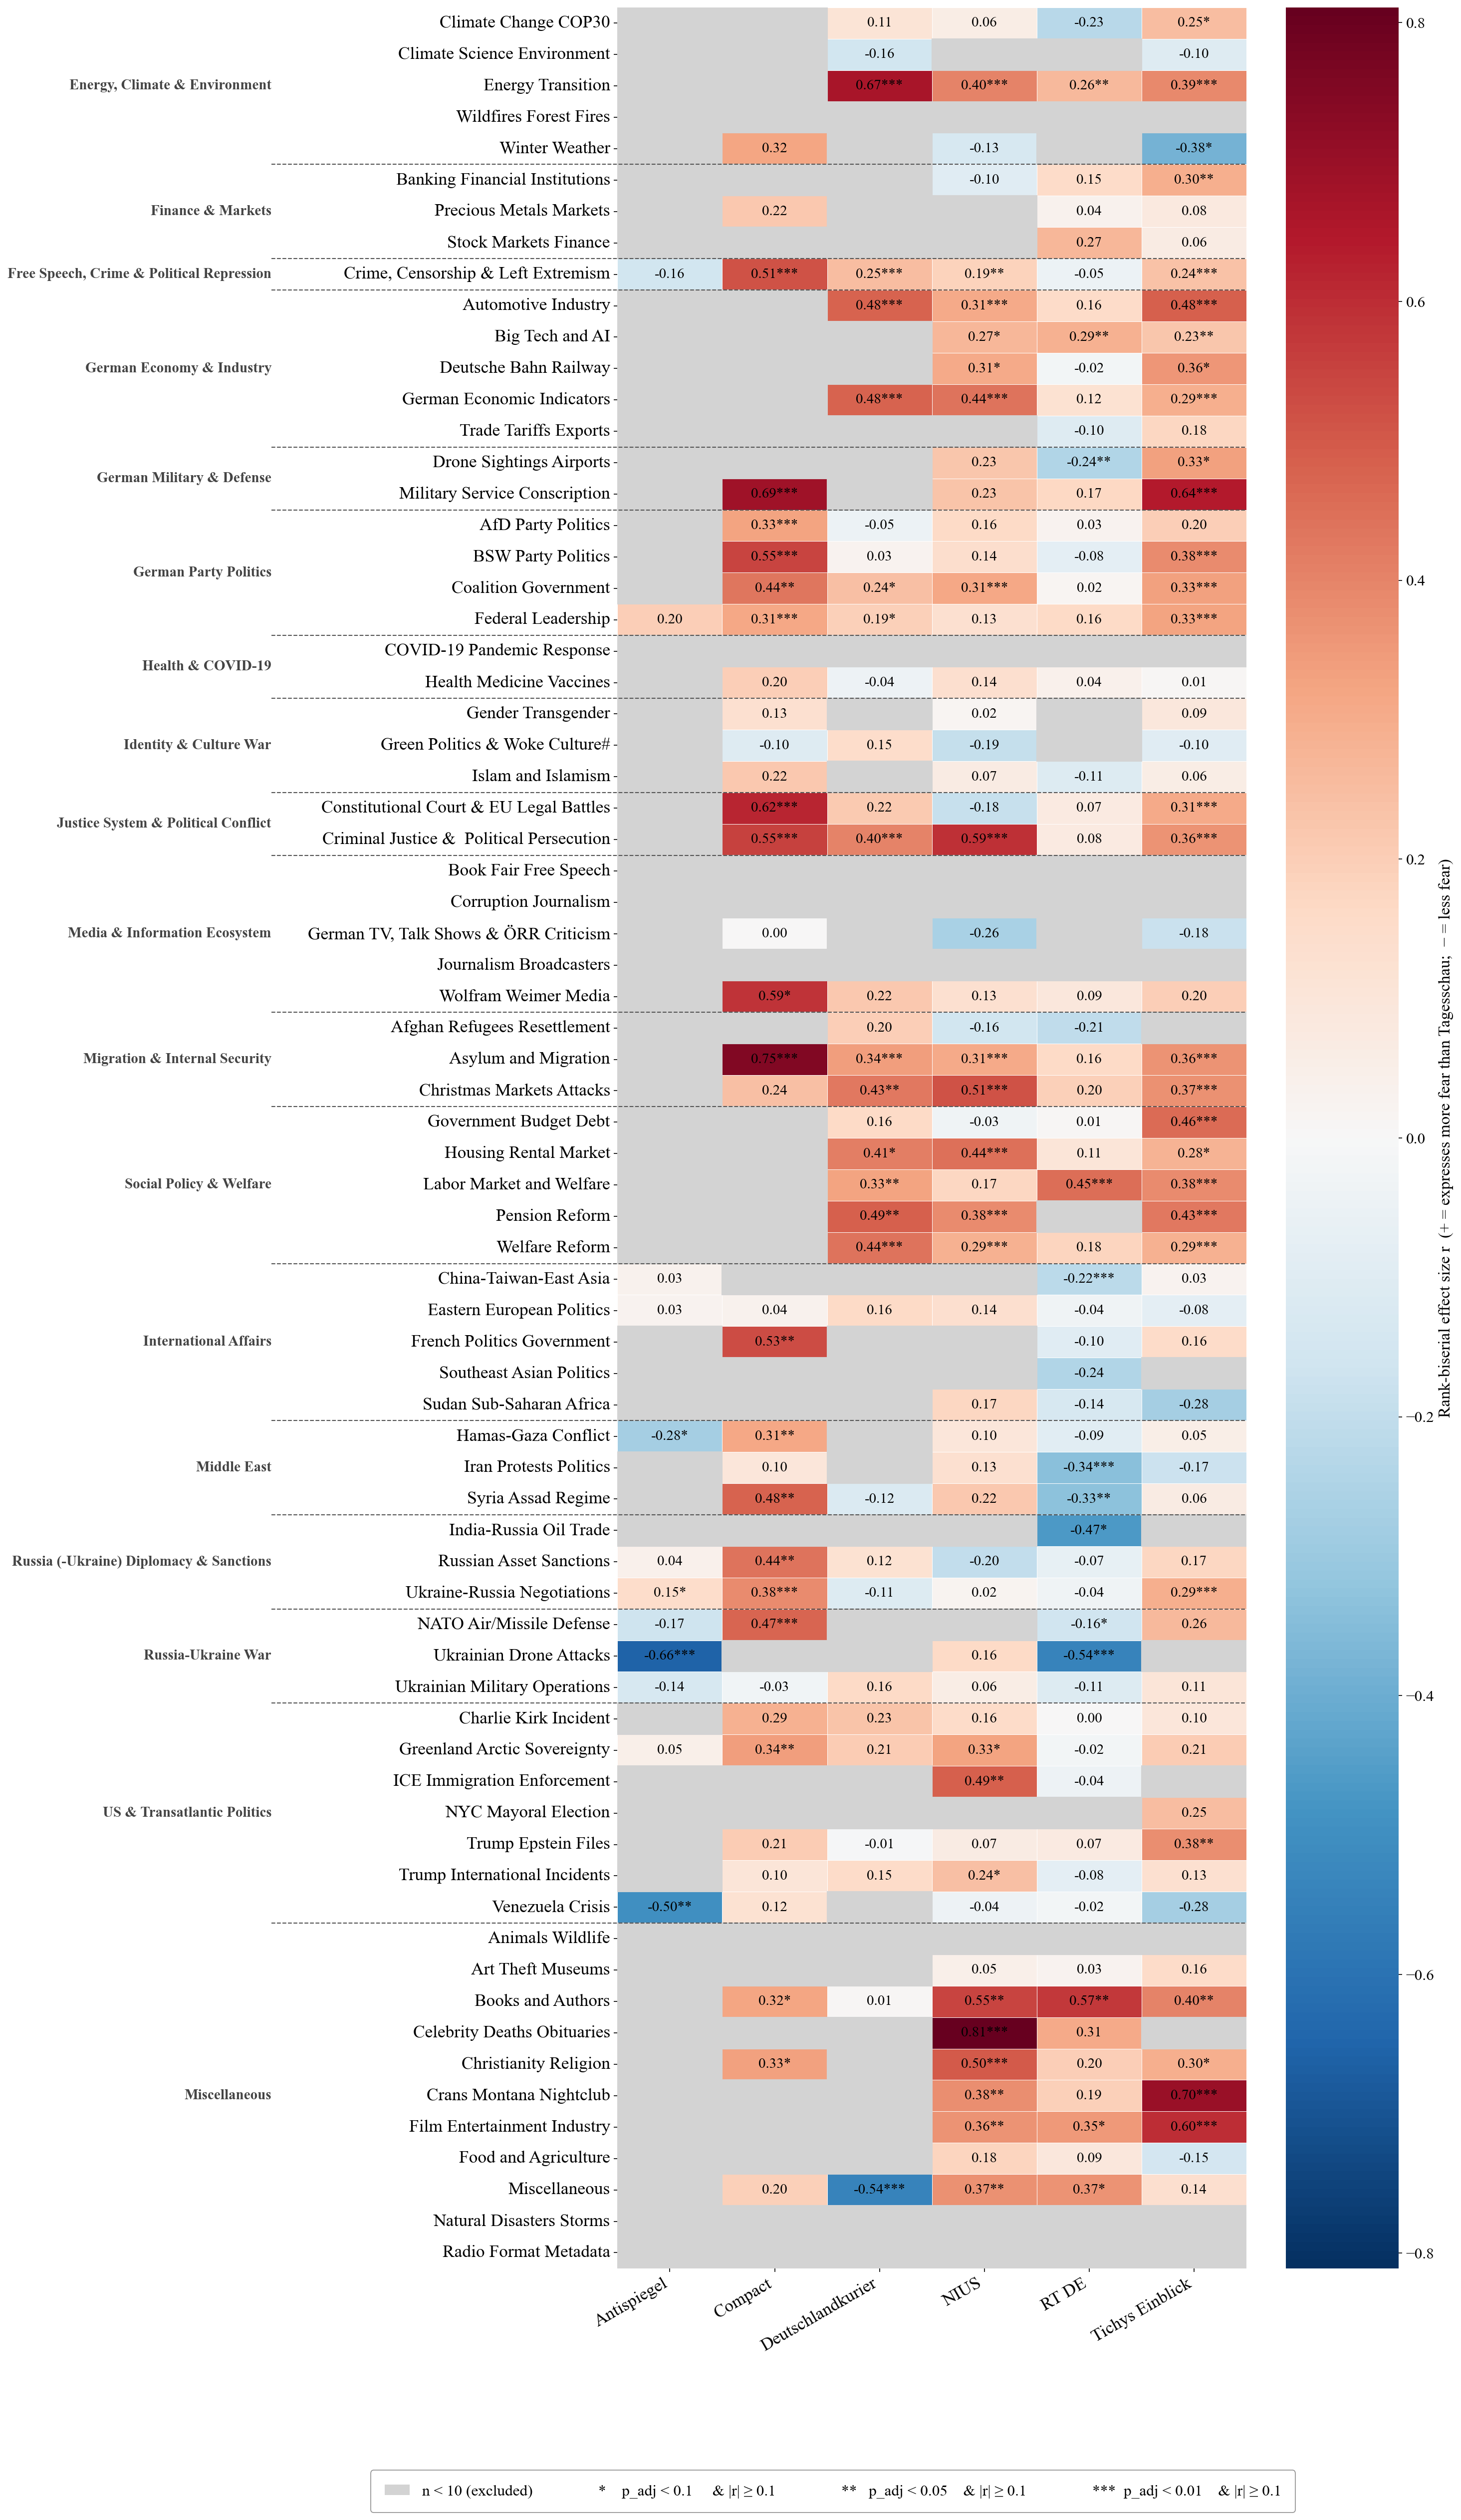

In [41]:
# ── Topic-level effect-size heatmap (fear), ordered by cluster ───────────────
# Uses the shared `_topic_level_heatmap` helper defined in the anger cell above.

CBAR_LABEL_FEAR_TOPIC = (
    "Rank-biserial effect size r  "
    "(+ = expresses more fear than Tagesschau;  − = less fear)"
)

results_topic_fear = _topic_level_heatmap("fear", CBAR_LABEL_FEAR_TOPIC, fig_id="topic_fear")